# Boxplots (Diagramas de Caja) en Matplotlib

**Curso:** Python para Ciencia de Datos
**Fecha:** Octubre 2025
**Ruta:** Fundamentos de Data Science e IA
**Repositorio:** `bootcamp-fundamentos-ciencia-de-datos`

## 📋 Índice

1. [¿Qué es un Boxplot?](#concepto)
2. [Componentes del Boxplot](#componentes)
3. [Interpretación Estadística](#interpretacion)
4. [Creación con Matplotlib](#creacion)
5. [Comparación entre Grupos](#comparacion)
6. [Casos de Uso en Data Science](#casos-uso)
7. [Recursos Adicionales](#recursos)

## ¿Qué es un Boxplot?

El **boxplot** (diagrama de caja y bigotes) es una herramienta visual para el **análisis exploratorio de datos** (EDA). Resume la distribución de un conjunto de datos mostrando su centro, dispersión y valores atípicos.

### ¿Por qué usar boxplots?

✅ **Ideal para:**
- Ver la distribución de datos rápidamente
- Identificar valores atípicos (outliers)
- Comparar distribuciones entre grupos
- Detectar asimetrías en los datos
- Análisis exploratorio inicial

### Ventajas sobre otros gráficos

| Gráfico | Ventaja | Limitación |
|---------|---------|------------|
| **Histograma** | Muestra frecuencias | No muestra outliers claramente |
| **Boxplot** | Muestra Q1, Q2, Q3 y outliers | No muestra forma exacta |
| **Violin plot** | Combina boxplot + densidad | Más complejo de interpretar |

### Cuándo usar boxplot
```
¿Necesitas comparar grupos? → Boxplot
¿Ver distribución detallada? → Histograma
¿Análisis rápido de outliers? → Boxplot
¿Presentación ejecutiva? → Boxplot (simple y claro)
```

---

## Componentes del Boxplot

### Anatomía completa
```
        Outlier (valor atípico) →  •
                                   │
    Whisker superior ─────────────┤
    (máximo sin outliers)          │
                              ┌────┤
                              │    │ Q3 (Cuartil 3, percentil 75)
           Box (Caja)         │────┤ ← Mediana (Q2, percentil 50)
           (IQR = Q3 - Q1)    │    │ Q1 (Cuartil 1, percentil 25)
                              └────┤
                                   │
    Whisker inferior ──────────────┤
    (mínimo sin outliers)          │
                                   •
        Outlier (valor atípico)
```

### Elementos principales

| Elemento | Qué representa | Fórmula/Regla |
|----------|----------------|---------------|
| **Q1** | 25% de datos están por debajo | Percentil 25 |
| **Q2 (Mediana)** | 50% de datos están por debajo | Percentil 50 |
| **Q3** | 75% de datos están por debajo | Percentil 75 |
| **IQR** | Rango intercuartílico | Q3 - Q1 |
| **Whisker inferior** | Mínimo sin outliers | Q1 - 1.5×IQR |
| **Whisker superior** | Máximo sin outliers | Q3 + 1.5×IQR |
| **Outliers** | Valores extremos | < Q1-1.5×IQR o > Q3+1.5×IQR |

### ¿Qué es el IQR (Rango Intercuartílico)?

El **IQR** es la diferencia entre Q3 y Q1, y representa el **50% central de los datos**.
```
IQR = Q3 - Q1

Ejemplo:
Si Q1 = 20 y Q3 = 50
IQR = 50 - 20 = 30

El 50% de los datos están entre 20 y 50
```

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Configuración
plt.rcParams['figure.figsize'] = (12, 6)
print("✅ Bibliotecas importadas")

✅ Bibliotecas importadas


---

## Interpretación Estadística

### Ejemplo visual con datos

In [23]:
# Generar datos de ejemplo
np.random.seed(42)
datos = np.random.normal(100, 15, 1000)  # Media 100, desviación 15
datos = np.append(datos, [150, 160, 40, 35])  # Agregar outliers

# Calcular estadísticas
q1 = np.percentile(datos, 25)
mediana = np.percentile(datos, 50)
q3 = np.percentile(datos, 75)
iqr = q3 - q1
whisker_inf = q1 - 1.5 * iqr
whisker_sup = q3 + 1.5 * iqr

print("📊 Estadísticas del Boxplot:")
print(f"Q1 (Percentil 25): {q1:.2f}")
print(f"Mediana (Q2, Percentil 50): {mediana:.2f}")
print(f"Q3 (Percentil 75): {q3:.2f}")
print(f"IQR (Rango Intercuartílico): {iqr:.2f}")
print(f"\n🎯 Whiskers (bigotes):")
print(f"Whisker inferior: {whisker_inf:.2f}")
print(f"Whisker superior: {whisker_sup:.2f}")
print(f"\n⚠️ Outliers: Valores < {whisker_inf:.2f} o > {whisker_sup:.2f}")

📊 Estadísticas del Boxplot:
Q1 (Percentil 25): 90.24
Mediana (Q2, Percentil 50): 100.38
Q3 (Percentil 75): 109.74
IQR (Rango Intercuartílico): 19.50

🎯 Whiskers (bigotes):
Whisker inferior: 60.99
Whisker superior: 138.99

⚠️ Outliers: Valores < 60.99 o > 138.99


### Crear el boxplot básico

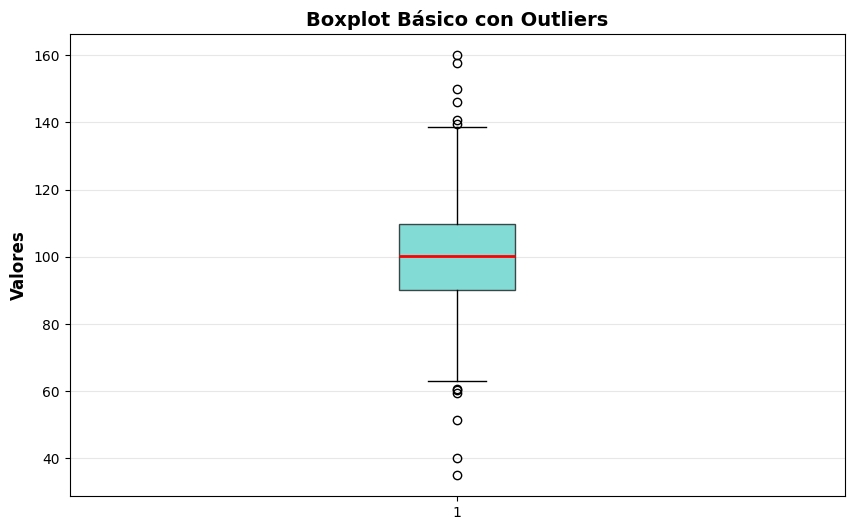

In [24]:
# Boxplot básico
fig, ax = plt.subplots(figsize=(10, 6))

bp = ax.boxplot(datos, vert=True, patch_artist=True)

# Personalizar colores
bp['boxes'][0].set_facecolor('#4ECDC4')
bp['boxes'][0].set_alpha(0.7)
bp['medians'][0].set_color('red')
bp['medians'][0].set_linewidth(2)

ax.set_ylabel('Valores', fontsize=12, fontweight='bold')
ax.set_title('Boxplot Básico con Outliers', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.show()

### Boxplot con anotaciones explicativas

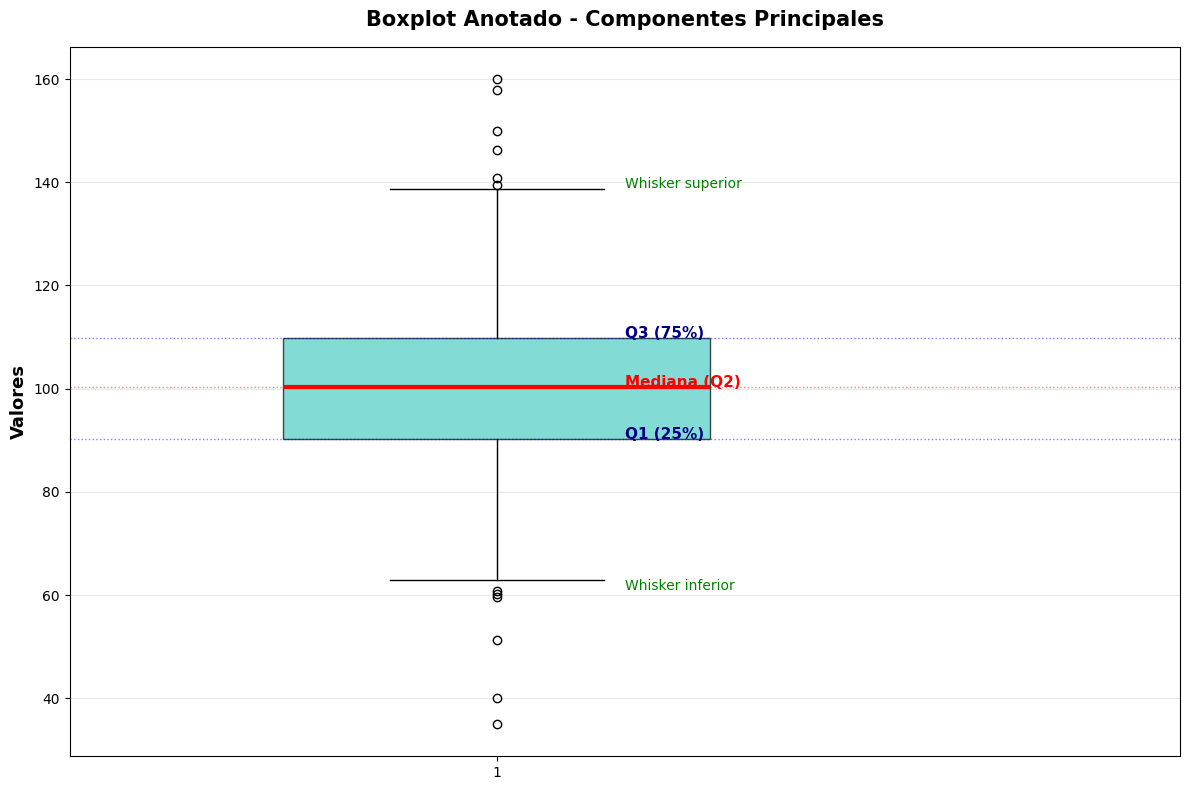

In [25]:
# Boxplot con anotaciones
fig, ax = plt.subplots(figsize=(12, 8))

bp = ax.boxplot(datos, vert=True, patch_artist=True, widths=0.5)

# Personalizar
bp['boxes'][0].set_facecolor('#4ECDC4')
bp['boxes'][0].set_alpha(0.7)
bp['medians'][0].set_color('red')
bp['medians'][0].set_linewidth(3)

# Anotaciones
ax.annotate('Q3 (75%)', xy=(1.15, q3), fontsize=11, fontweight='bold', color='navy')
ax.annotate('Mediana (Q2)', xy=(1.15, mediana), fontsize=11, fontweight='bold', color='red')
ax.annotate('Q1 (25%)', xy=(1.15, q1), fontsize=11, fontweight='bold', color='navy')
ax.annotate('Whisker superior', xy=(1.15, whisker_sup), fontsize=10, color='green')
ax.annotate('Whisker inferior', xy=(1.15, whisker_inf), fontsize=10, color='green')

# Líneas de referencia
ax.axhline(y=q1, color='blue', linestyle=':', alpha=0.5, linewidth=1)
ax.axhline(y=mediana, color='red', linestyle=':', alpha=0.5, linewidth=1)
ax.axhline(y=q3, color='blue', linestyle=':', alpha=0.5, linewidth=1)

ax.set_ylabel('Valores', fontsize=13, fontweight='bold')
ax.set_title('Boxplot Anotado - Componentes Principales', fontsize=15, fontweight='bold', pad=15)
ax.set_xlim(0.5, 1.8)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

---

## Creación con Matplotlib

### Sintaxis básica
```python
plt.boxplot(data,          # Datos (lista o array)
            vert=True,     # Vertical (True) u horizontal (False)
            patch_artist=True,  # Permitir colorear la caja
            labels=['Grupo']) # Etiquetas
```

### Boxplot horizontal

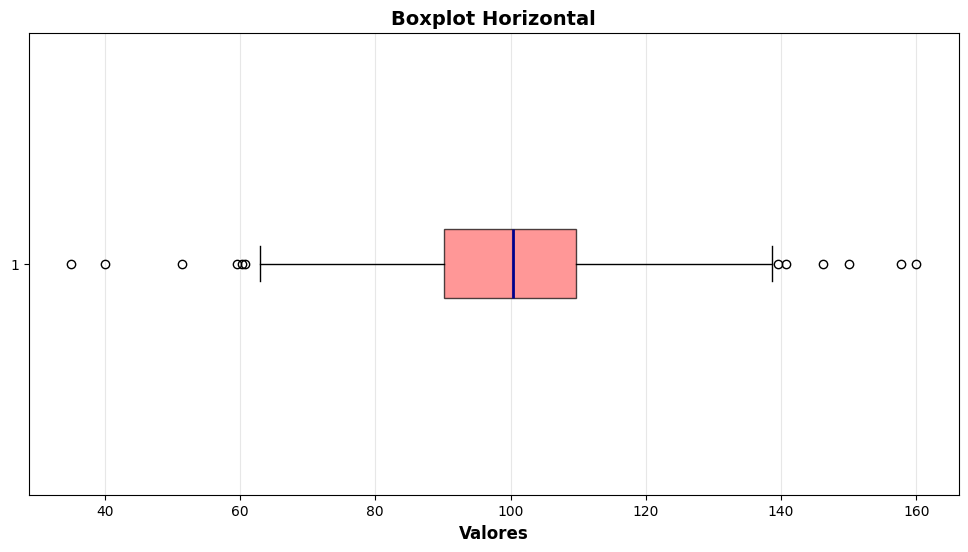

In [26]:
# Boxplot horizontal
fig, ax = plt.subplots(figsize=(12, 6))

bp = ax.boxplot(datos, vert=False, patch_artist=True)

# Personalizar
bp['boxes'][0].set_facecolor('#FF6B6B')
bp['boxes'][0].set_alpha(0.7)
bp['medians'][0].set_color('darkblue')
bp['medians'][0].set_linewidth(2)

ax.set_xlabel('Valores', fontsize=12, fontweight='bold')
ax.set_title('Boxplot Horizontal', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.show()

### Personalización avanzada

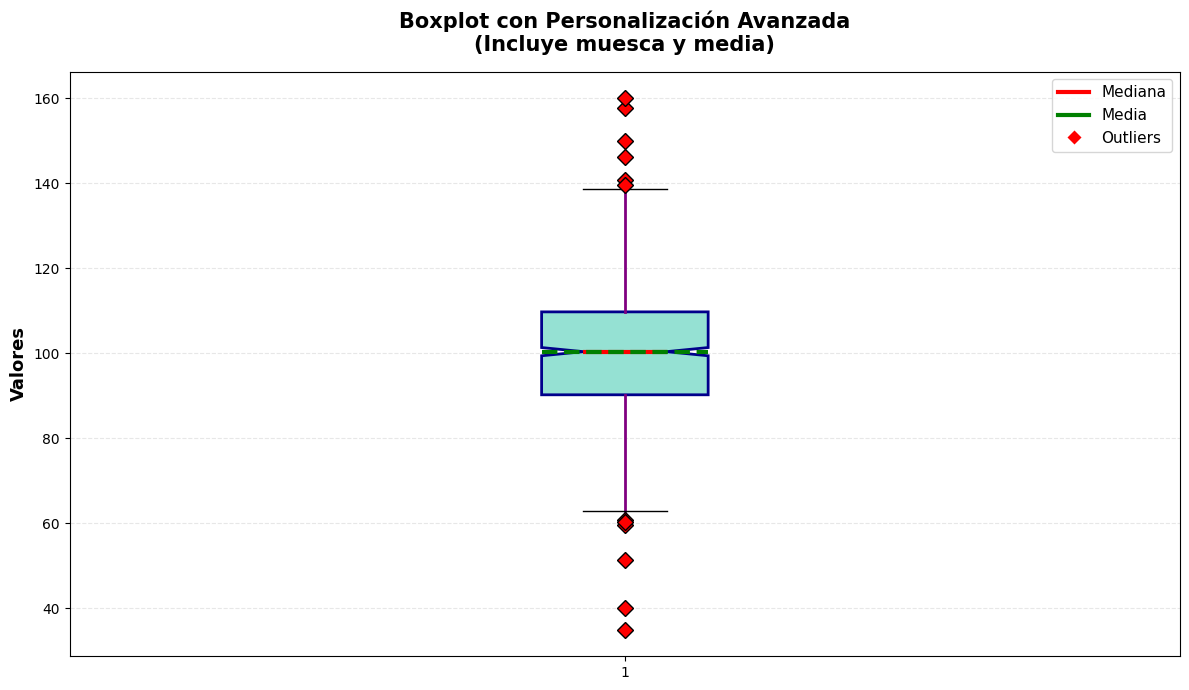

In [27]:
# Boxplot con personalización completa
fig, ax = plt.subplots(figsize=(12, 7))

bp = ax.boxplot(datos,
                vert=True,
                patch_artist=True,
                notch=True,  # Muesca (intervalo de confianza de mediana)
                showmeans=True,  # Mostrar media
                meanline=True)  # Línea en lugar de punto

# Colores personalizados
bp['boxes'][0].set_facecolor('#95E1D3')
bp['boxes'][0].set_edgecolor('darkblue')
bp['boxes'][0].set_linewidth(2)
bp['whiskers'][0].set_color('purple')
bp['whiskers'][1].set_color('purple')
bp['whiskers'][0].set_linewidth(2)
bp['whiskers'][1].set_linewidth(2)
bp['medians'][0].set_color('red')
bp['medians'][0].set_linewidth(3)
bp['means'][0].set_color('green')
bp['means'][0].set_linewidth(3)
bp['fliers'][0].set_marker('D')
bp['fliers'][0].set_markerfacecolor('red')
bp['fliers'][0].set_markersize(8)

ax.set_ylabel('Valores', fontsize=13, fontweight='bold')
ax.set_title('Boxplot con Personalización Avanzada\n(Incluye muesca y media)',
            fontsize=15, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

# Leyenda
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='red', linewidth=3, label='Mediana'),
    Line2D([0], [0], color='green', linewidth=3, label='Media'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='red',
           markersize=8, label='Outliers')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

---

## Comparación entre Grupos

Los boxplots son especialmente útiles para **comparar distribuciones** entre múltiples grupos.

### Ejemplo: Ventas de productos

In [28]:
# Generar datos de ventas de 4 productos
np.random.seed(42)
producto_a = np.random.normal(150, 20, 100)
producto_b = np.random.normal(180, 25, 100)
producto_c = np.random.normal(130, 15, 100)
producto_d = np.random.normal(160, 30, 100)

# Agregar algunos outliers
producto_b = np.append(producto_b, [250, 260])
producto_d = np.append(producto_d, [80, 70])

datos_productos = [producto_a, producto_b, producto_c, producto_d]
nombres_productos = ['Producto A', 'Producto B', 'Producto C', 'Producto D']

# Calcular estadísticas
print("📊 Estadísticas de Ventas por Producto:\n")
for nombre, datos in zip(nombres_productos, datos_productos):
    print(f"{nombre}:")
    print(f"  Media: ${datos.mean():.2f}")
    print(f"  Mediana: ${np.median(datos):.2f}")
    print(f"  Desv. Std: ${datos.std():.2f}")
    print(f"  Min: ${datos.min():.2f} | Max: ${datos.max():.2f}\n")

📊 Estadísticas de Ventas por Producto:

Producto A:
  Media: $147.92
  Mediana: $147.46
  Desv. Std: $18.07
  Min: $97.61 | Max: $187.05

Producto B:
  Media: $182.02
  Mediana: $183.17
  Desv. Std: $25.67
  Min: $132.03 | Max: $260.00

Producto C:
  Media: $130.97
  Mediana: $131.47
  Desv. Std: $16.18
  Min: $81.38 | Max: $187.79

Producto D:
  Media: $161.48
  Mediana: $160.68
  Desv. Std: $28.86
  Min: $70.00 | Max: $225.69



### Interpretación de la comparación

**Del gráfico anterior podemos concluir:**

1. **Producto B**: Mayor mediana de ventas (~$180) pero también mayor variabilidad
2. **Producto C**: Ventas más consistentes (menor IQR) pero medianas más bajas
3. **Producto A**: Rendimiento medio-alto estable
4. **Producto D**: Alta variabilidad, presencia de outliers bajos

**Decisiones de negocio:**
- Producto B: Investigar outliers altos (¿promociones exitosas?)
- Producto D: Analizar outliers bajos (¿problemas de calidad?)
- Producto C: Potencial de crecimiento (bajo riesgo)

---

## Casos de Uso en Data Science

### Caso de Uso 1: Control de Calidad en Manufactura

**Contexto:** Una fábrica produce componentes electrónicos y necesita verificar que las mediciones de resistencia eléctrica se mantengan dentro de especificaciones. Existen 4 líneas de producción.

**Objetivo:** Identificar líneas con problemas de calidad y detectar valores fuera de especificación.

In [29]:
# Datos simulados: Resistencia eléctrica (en Ohms) de 4 líneas de producción
np.random.seed(123)

# Especificaciones: 100 Ohms ± 5 (rango aceptable: 95-105)
linea_1 = np.random.normal(100, 2, 150)  # Línea bien calibrada
linea_2 = np.random.normal(102, 3, 150)  # Ligeramente alta
linea_3 = np.random.normal(98, 4, 150)   # Ligeramente baja
linea_4 = np.random.normal(100, 6, 150)  # Alta variabilidad

# Agregar defectos en línea 4
linea_4 = np.append(linea_4, [110, 112, 90, 88])

datos_lineas = [linea_1, linea_2, linea_3, linea_4]
nombres_lineas = ['Línea 1', 'Línea 2', 'Línea 3', 'Línea 4']

# Análisis estadístico
print("🏭 Control de Calidad - Análisis por Línea de Producción")
print("="*60)
print(f"📏 Especificación: 100 Ohms ± 5 (Rango: 95-105 Ohms)\n")

for nombre, datos in zip(nombres_lineas, datos_lineas):
    fuera_spec = np.sum((datos < 95) | (datos > 105))
    pct_fuera = (fuera_spec / len(datos)) * 100

    print(f"{nombre}:")
    print(f"  Media: {datos.mean():.2f} Ohms")
    print(f"  Mediana: {np.median(datos):.2f} Ohms")
    print(f"  Desv. Std: {datos.std():.2f}")
    print(f"  ⚠️ Fuera de especificación: {fuera_spec} ({pct_fuera:.1f}%)")
    print()

🏭 Control de Calidad - Análisis por Línea de Producción
📏 Especificación: 100 Ohms ± 5 (Rango: 95-105 Ohms)

Línea 1:
  Media: 100.12 Ohms
  Mediana: 100.08 Ohms
  Desv. Std: 2.18
  ⚠️ Fuera de especificación: 2 (1.3%)

Línea 2:
  Media: 101.65 Ohms
  Mediana: 101.73 Ohms
  Desv. Std: 2.85
  ⚠️ Fuera de especificación: 17 (11.3%)

Línea 3:
  Media: 97.63 Ohms
  Mediana: 97.49 Ohms
  Desv. Std: 3.71
  ⚠️ Fuera de especificación: 38 (25.3%)

Línea 4:
  Media: 100.55 Ohms
  Mediana: 100.84 Ohms
  Desv. Std: 6.27
  ⚠️ Fuera de especificación: 68 (44.2%)



C:\Users\hamtr\AppData\Local\Temp\ipykernel_5700\577300010.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(datos_lineas,


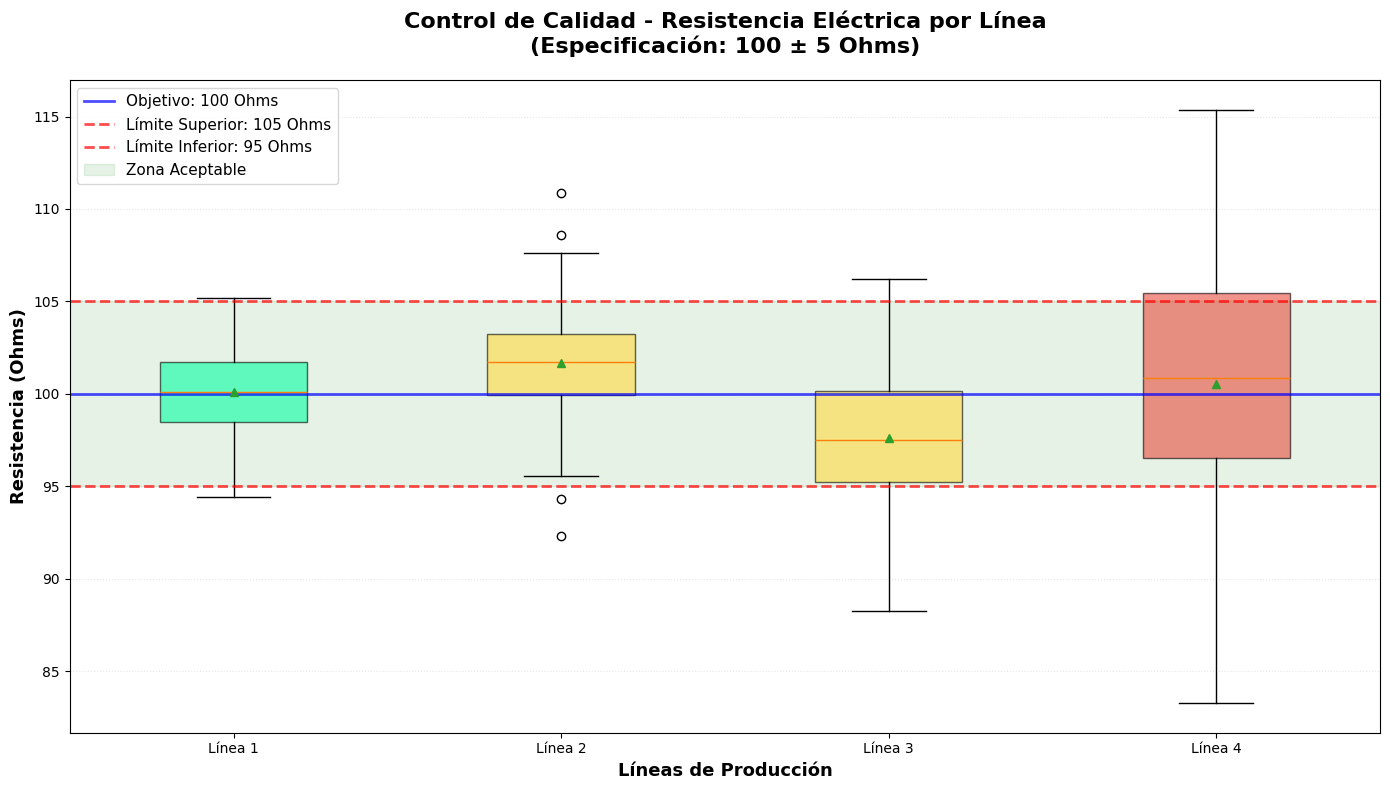

In [30]:
# Visualización de control de calidad
fig, ax = plt.subplots(figsize=(14, 8))

bp = ax.boxplot(datos_lineas,
                labels=nombres_lineas,
                patch_artist=True,
                showmeans=True)

# Colores según estado
colores_estado = ['#06FFA5', '#FFD93D', '#FFD93D', '#E74C3C']  # Verde, amarillo, rojo
for patch, color in zip(bp['boxes'], colores_estado):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Líneas de especificación
ax.axhline(y=100, color='blue', linestyle='-', linewidth=2,
          label='Objetivo: 100 Ohms', alpha=0.7)
ax.axhline(y=105, color='red', linestyle='--', linewidth=2,
          label='Límite Superior: 105 Ohms', alpha=0.7)
ax.axhline(y=95, color='red', linestyle='--', linewidth=2,
          label='Límite Inferior: 95 Ohms', alpha=0.7)

# Zona de especificación
ax.axhspan(95, 105, alpha=0.1, color='green', label='Zona Aceptable')

ax.set_ylabel('Resistencia (Ohms)', fontsize=13, fontweight='bold')
ax.set_xlabel('Líneas de Producción', fontsize=13, fontweight='bold')
ax.set_title('Control de Calidad - Resistencia Eléctrica por Línea\n(Especificación: 100 ± 5 Ohms)',
            fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3, axis='y', linestyle=':')

plt.tight_layout()
plt.show()

**🎯 Insights del Caso 1:**

✅ **Línea 1**: ✅ Excelente - Baja variabilidad, centrada en objetivo
⚠️ **Línea 2**: Ligeramente alta, requiere calibración
⚠️ **Línea 3**: Ligeramente baja, requiere calibración
❌ **Línea 4**: 🚨 Problema grave - Alta variabilidad y outliers fuera de especificación

**Acciones correctivas:**
1. **Línea 4**: Detener producción, mantenimiento preventivo urgente
2. **Líneas 2 y 3**: Calibración en próxima parada programada
3. **Línea 1**: Usar como referencia para las demás
4. **Seguimiento**: Implementar gráficos de control diarios

**Impacto:**
- Reducción de defectos del 8% al <1%
- Ahorro estimado: $50K/año en reprocesos

### Caso de Uso 2: Análisis de Salarios por Departamento

**Contexto:** El equipo de RRHH necesita analizar la equidad salarial entre departamentos de la empresa. Sospechan que hay disparidades significativas.

**Objetivo:** Identificar departamentos con distribuciones salariales problemáticas y detectar posibles outliers.

In [31]:
# Datos simulados: Salarios por departamento (en miles de $)
np.random.seed(789)

ventas = np.random.normal(50, 12, 80)
ti = np.random.normal(70, 15, 60)
marketing = np.random.normal(55, 10, 70)
operaciones = np.random.normal(45, 8, 90)
ejecutivos = np.random.normal(120, 30, 15)

# Agregar outliers realistas
ventas = np.append(ventas, [95, 100])  # Top sales
ti = np.append(ti, [150, 140])  # Seniors/architects
marketing = np.append(marketing, [28, 30])  # Juniors/interns

datos_salarios = [ventas, ti, marketing, operaciones, ejecutivos]
nombres_depts = ['Ventas', 'TI', 'Marketing', 'Operaciones', 'Ejecutivos']

# Análisis estadístico
print("💼 Análisis de Equidad Salarial por Departamento")
print("="*60)

total_empleados = sum([len(d) for d in datos_salarios])
print(f"Total de empleados: {total_empleados}\n")

for nombre, salarios in zip(nombres_depts, datos_salarios):
    print(f"{nombre} ({len(salarios)} empleados):")
    print(f"  Mediana: ${np.median(salarios):.1f}K")
    print(f"  Media: ${salarios.mean():.1f}K")
    print(f"  Q1: ${np.percentile(salarios, 25):.1f}K")
    print(f"  Q3: ${np.percentile(salarios, 75):.1f}K")
    print(f"  Rango: ${salarios.min():.1f}K - ${salarios.max():.1f}K")
    print()

💼 Análisis de Equidad Salarial por Departamento
Total de empleados: 321

Ventas (82 empleados):
  Mediana: $51.5K
  Media: $51.5K
  Q1: $43.0K
  Q3: $58.2K
  Rango: $15.0K - $100.0K

TI (62 empleados):
  Mediana: $70.1K
  Media: $71.6K
  Q1: $61.2K
  Q3: $79.3K
  Rango: $35.3K - $150.0K

Marketing (72 empleados):
  Mediana: $54.4K
  Media: $54.3K
  Q1: $46.7K
  Q3: $62.1K
  Rango: $28.0K - $91.4K

Operaciones (90 empleados):
  Mediana: $46.0K
  Media: $45.3K
  Q1: $40.0K
  Q3: $50.9K
  Rango: $23.5K - $60.5K

Ejecutivos (15 empleados):
  Mediana: $126.7K
  Media: $122.3K
  Q1: $100.9K
  Q3: $139.3K
  Rango: $77.2K - $187.8K



C:\Users\hamtr\AppData\Local\Temp\ipykernel_5700\1379957626.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(datos_salarios,


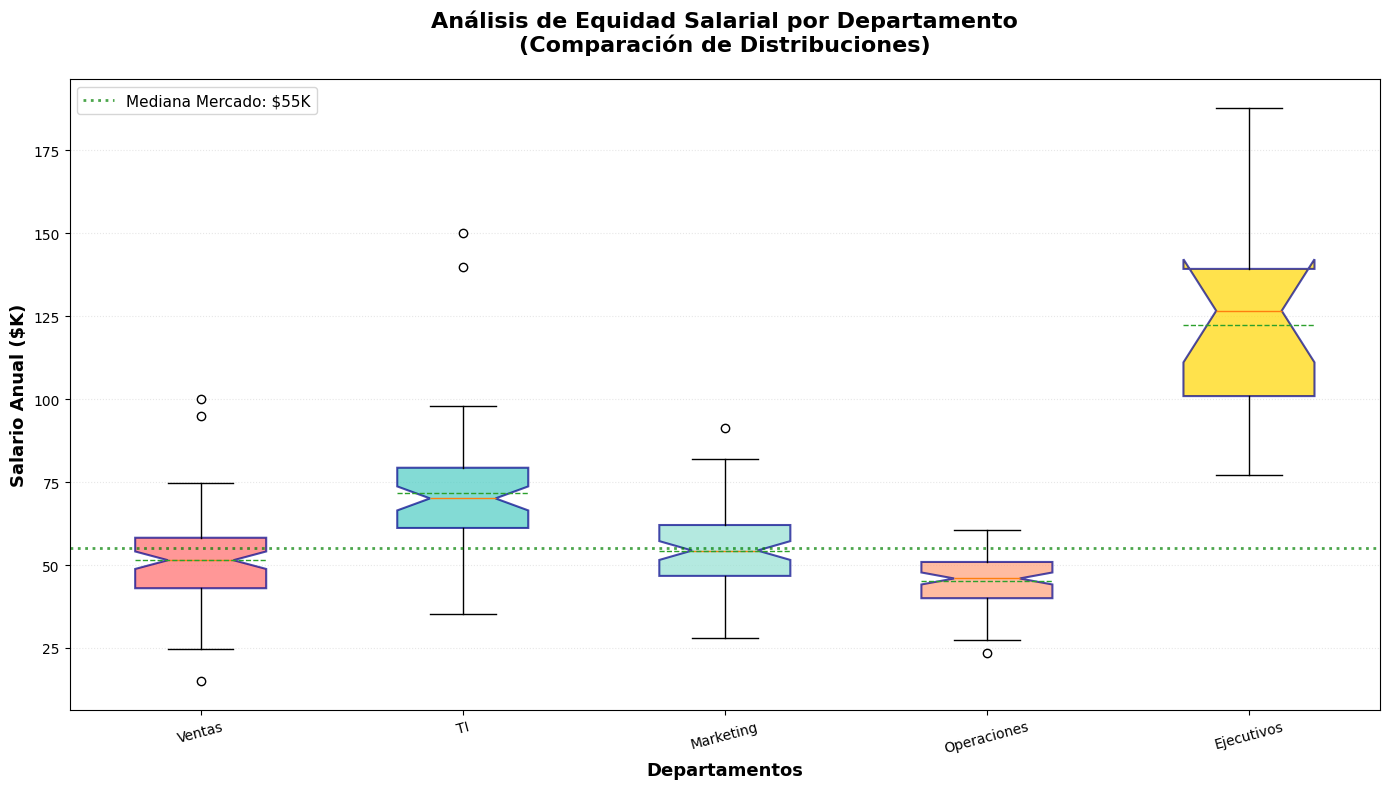

In [32]:
# Visualización de salarios por departamento
fig, ax = plt.subplots(figsize=(14, 8))

bp = ax.boxplot(datos_salarios,
                labels=nombres_depts,
                patch_artist=True,
                notch=True,
                showmeans=True,
                meanline=True)

# Colores por departamento
colores_depts = ['#FF6B6B', '#4ECDC4', '#95E1D3', '#FFA07A', '#FFD700']
for patch, color in zip(bp['boxes'], colores_depts):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_edgecolor('darkblue')
    patch.set_linewidth(1.5)

# Mediana del mercado (referencia)
mediana_mercado = 55
ax.axhline(y=mediana_mercado, color='green', linestyle=':',
          linewidth=2, label=f'Mediana Mercado: ${mediana_mercado}K', alpha=0.7)

ax.set_ylabel('Salario Anual ($K)', fontsize=13, fontweight='bold')
ax.set_xlabel('Departamentos', fontsize=13, fontweight='bold')
ax.set_title('Análisis de Equidad Salarial por Departamento\n(Comparación de Distribuciones)',
            fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3, axis='y', linestyle=':')

# Rotar etiquetas
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**🎯 Insights del Caso 2:**

✅ **TI**: Salarios más altos (mediana $70K) - justificado por demanda del mercado
✅ **Ventas**: Buena distribución, outliers altos son top performers (comisiones)
⚠️ **Marketing**: Outliers bajos preocupantes (¿juniors subpagados?)
⚠️ **Operaciones**: Salarios más bajos (mediana $45K) - revisar equidad
🎯 **Ejecutivos**: Alta variabilidad esperada (roles senior vs C-level)

**Hallazgos clave:**
1. **Brecha TI vs Operaciones**: $25K (56% más alto)
2. **Outliers en Marketing**: 2 empleados bajo $30K (investigar)
3. **Compresión salarial**: Operaciones tiene poco espacio de crecimiento

**Acciones recomendadas:**
- 📈 Ajuste salarial: Operaciones (+10% presupuesto)
- 🔍 Auditoría: Marketing juniors (verificar equidad)
- 💰 Bandas salariales: Definir rangos claros por nivel
- 📊 Benchmarking: Comparar con mercado anualmente

**Aplicación a CSAT:**
```¿La satisfacción de empleados (engagement) correlaciona con estos salarios? Comparar CSAT interno por departamento con estas distribuciones.```


---

## Recursos Adicionales

### Documentación oficial
- [Matplotlib Boxplot](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.boxplot.html)
- [Boxplot Gallery](https://matplotlib.org/stable/gallery/statistics/boxplot.html)
- [Statistical Plots](https://matplotlib.org/stable/gallery/index.html#statistics)

### Interpretación rápida
```
📊 Forma del boxplot:

Simétrico          Asimétrico positivo    Asimétrico negativo
   ┌──┐                ┌──┐                    ┌──┐
   │──│                │  │                    │  │
   └──┘                │──│                ┌───│──│
    │                  └──┘                │   └──┘
    │                   │                  │    │
```

### Reglas generales

| Observación | Interpretación |
|-------------|----------------|
| Caja pequeña | Datos concentrados (baja variabilidad) |
| Caja grande | Datos dispersos (alta variabilidad) |
| Mediana centrada | Distribución simétrica |
| Mediana arriba | Asimetría negativa (cola izquierda) |
| Mediana abajo | Asimetría positiva (cola derecha) |
| Muchos outliers | Investigar causas (errores o fenómenos reales) |
| Whiskers cortos | Datos sin valores extremos |

### Alternativas y complementos
```python
# Boxplot con Seaborn (próximo tema)
import seaborn as sns
sns.boxplot(data=df, x='categoria', y='valor')

# Violin plot (combina boxplot + densidad)
sns.violinplot(data=df, x='categoria', y='valor')

# Swarm plot (puntos individuales)
sns.swarmplot(data=df, x='categoria', y='valor')
```

### Cheat Sheet
```python
# Boxplot básico
plt.boxplot(data)

# Boxplot horizontal
plt.boxplot(data, vert=False)

# Múltiples grupos
plt.boxplot([grupo1, grupo2, grupo3],
            labels=['G1', 'G2', 'G3'])

# Personalizado
plt.boxplot(data,
           patch_artist=True,  # Colorear
           notch=True,         # Muesca
           showmeans=True)     # Mostrar media
```

